# 01 — 2022 Ground Effect Era Baseline

Establishes the competitive baseline for the 2022–2025 Ground Effect Era across four metrics:

1. **Constructor points spread** — Gini coefficient and P1–P10 gap by season
2. **Lap time field spread** — P1–P10 fastest lap gap per race, averaged by season
3. **Reliability** — DNF rates by constructor and year
4. **Qualifying conversion** — how consistently teams/drivers convert grid position to race result

These metrics form the comparison baseline for the 2026 era analysis in notebook 02.

> **Note on data loading:** FastF1 loads each session individually. The first run across all four seasons (2022–2025) will take several minutes as the cache populates. Subsequent runs are fast. Run cells in order.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.fastf1_loader import load_session, get_event_schedule, get_race_control_flags
from src.utils.era_helper import get_year_within_era
from src.analysis.points_spread import points_gini_by_round, season_end_gini, points_gap_by_round
from src.analysis.reliability import dnf_rate_by_constructor_year, dnf_causes
from src.analysis.lap_time_delta import fastest_lap_per_driver, p1_to_pn_gap, lap_time_delta_summary, mean_gap_by_season
from src.analysis.quali_race_delta import quali_race_delta, mean_delta_by_constructor

sns.set_theme(style='whitegrid', palette='muted')
GROUND_EFFECT_SEASONS = [2022, 2023, 2024, 2025]
print('Libraries loaded.')

Libraries loaded.


## Load Race Results (2022–2025)

Iterates every race session across the era and builds a flat results DataFrame.
This is the main data loading cell — expect it to take a few minutes on first run.

In [2]:
all_results = []
all_laps = {}  # (season, round) -> laps DataFrame

_SPRINT_FORMATS = {'sprint', 'sprint_shootout', 'sprint_qualifying'}
_DNS_STATUSES = {'Did not start', 'Did not qualify', 'Withdrew'}

for season in GROUND_EFFECT_SEASONS:
    schedule = get_event_schedule(season)
    # Exclude pre-season testing only — sprint weekend formats have changed across
    # seasons: 'sprint' (2022), 'sprint_shootout' (2023), 'sprint_qualifying' (2024+).
    races = schedule[schedule['EventFormat'] != 'testing']

    for _, event in races.iterrows():
        round_num = int(event['RoundNumber'])
        event_name = event['EventName']
        is_sprint_wknd = event['EventFormat'] in _SPRINT_FORMATS

        try:
            session = load_session(season, round_num, 'R')
            results = session.results
            laps = session.laps
            rc_flags = get_race_control_flags(session)

            for _, driver in results.iterrows():
                finish_pos = driver.get('Position')
                grid_pos = driver.get('GridPosition')
                pts = driver.get('Points')
                status = driver.get('Status', '')
                dns = status in _DNS_STATUSES
                all_results.append({
                    'season': season,
                    'round': round_num,
                    'race_name': event_name,
                    'is_sprint_weekend': is_sprint_wknd,
                    'driver_id': driver.get('Abbreviation', ''),
                    'driver_name': f"{driver.get('FirstName', '')} {driver.get('LastName', '')}".strip(),
                    'constructor_id': str(driver.get('TeamId', '')).lower().replace(' ', '_'),
                    'constructor_name': driver.get('TeamName', ''),
                    # grid_position=None when missing or 0 (pit lane start recorded as 0
                    # by FastF1) — excludes these rows from quali→race delta calculation.
                    # 2022 sprint weekends: grid set by sprint result, not qualifying.
                    'grid_position': int(grid_pos) if pd.notna(grid_pos) and int(grid_pos) > 0 else None,
                    'finish_position': None if dns or not pd.notna(finish_pos) else int(finish_pos),
                    'points': float(pts) if pd.notna(pts) else 0.0,
                    'status': status,
                    'had_sc': rc_flags['had_sc'],
                    'had_vsc': rc_flags['had_vsc'],
                    'had_red_flag': rc_flags['had_red_flag'],
                })

            all_laps[(season, round_num)] = laps
            flags_tag = ''.join([
                ' SC' if rc_flags['had_sc'] else '',
                ' VSC' if rc_flags['had_vsc'] else '',
                ' RF' if rc_flags['had_red_flag'] else '',
            ])
            sprint_tag = ' [sprint wknd]' if is_sprint_wknd else ''
            print(f'  {season} R{round_num:02d} {event_name}{sprint_tag}{flags_tag} — {len(results)} drivers loaded')

        except Exception as e:
            print(f'  {season} R{round_num:02d} {event_name} — SKIPPED ({e})')

results_df = pd.DataFrame(all_results)
print(f'\nTotal race entries loaded: {len(results_df)}')
print(f'Seasons: {sorted(results_df["season"].unique())}')
print(f'Races:   {results_df[["season","round"]].drop_duplicates().shape[0]}')

sprint_counts = results_df[results_df['is_sprint_weekend']].groupby('season')['round'].nunique()
print(f'\nSprint weekend rounds by season:\n{sprint_counts.to_string()}')

# Race control event summary
rc_summary = results_df.drop_duplicates(['season', 'round'])[['season', 'round', 'had_sc', 'had_vsc', 'had_red_flag']]
print(f'\nRace control events across {len(rc_summary)} races:')
print(f'  Safety car:         {rc_summary["had_sc"].sum()} races')
print(f'  Virtual safety car: {rc_summary["had_vsc"].sum()} races')
print(f'  Red flag:           {rc_summary["had_red_flag"].sum()} races')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 

  2022 R01 Bahrain Grand Prix SC VSC — 20 drivers loaded


core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap

  2022 R02 Saudi Arabian Grand Prix SC VSC — 20 drivers loaded


core        WARNING 	Driver 16 completed the race distance 00:00.140000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '11', '63', '44', '4', '3', '31', '77', '10', '23', '24', '18', '47', '20', '22', '6', '14', '1', '5', '55']
core           INFO 	Loading data for Emilia Romagna Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_

...

  2025 R22 Las Vegas Grand Prix VSC — 20 drivers loaded


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  2025 R23 Qatar Grand Prix [sprint wknd] SC — 20 drivers loaded


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  2025 R24 Abu Dhabi Grand Prix — 20 drivers loaded

Total race entries loaded: 1838
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Races:   92

Sprint weekend rounds by season:
season
2022    3
2023    6
2024    6
2025    6

Race control events across 92 races:
  Safety car:         49 races
  Virtual safety car: 42 races
  Red flag:           11 races


In [3]:
# Normalise constructor IDs across mid-era rebrands.
# AlphaTauri rebranded to RB (Racing Bulls) for 2024.
# Alfa Romeo rebranded to Sauber (Stake F1 Team) for 2024.
# Merging under the current name keeps the full era arc in one continuous series.
_CONSTRUCTOR_ALIASES = {
    'alphatauri': 'rb',
    'alfa':       'sauber',
}
_CONSTRUCTOR_DISPLAY = {
    'rb':     'Racing Bulls / AlphaTauri',
    'sauber': 'Sauber / Alfa Romeo',
}

results_df['constructor_id'] = results_df['constructor_id'].replace(_CONSTRUCTOR_ALIASES)
results_df['constructor_name'] = (
    results_df['constructor_id']
    .map(_CONSTRUCTOR_DISPLAY)
    .fillna(results_df['constructor_name'])
)

print('Constructor normalisation applied.')
print(results_df[['constructor_id', 'constructor_name']].drop_duplicates()
      .sort_values('constructor_id').to_string(index=False))

Constructor normalisation applied.
constructor_id          constructor_name
        alpine                    Alpine
  aston_martin              Aston Martin
       ferrari                   Ferrari
          haas              Haas F1 Team
       mclaren                   McLaren
      mercedes                  Mercedes
            rb Racing Bulls / AlphaTauri
      red_bull           Red Bull Racing
        sauber       Sauber / Alfa Romeo
      williams                  Williams


## 1. Constructor Points Spread

**Gini coefficient** measures how unevenly points are distributed across constructors.
- 0 = all constructors have equal points (maximum parity)
- 1 = one constructor has all the points (minimum parity)

A falling Gini across era years indicates field convergence.

In [4]:
# Build cumulative constructor standings by round
standings_rows = []
for season in GROUND_EFFECT_SEASONS:
    season_df = results_df[results_df['season'] == season].copy()
    season_df = season_df.sort_values('round')
    cumulative = season_df.groupby(['constructor_id', 'round'])['points'].sum().groupby('constructor_id').cumsum().reset_index()
    cumulative['season'] = season
    cumulative.columns = ['constructor_id', 'round', 'points', 'season']
    standings_rows.append(cumulative)

standings_df = pd.concat(standings_rows, ignore_index=True)
standings_df.head()

,constructor_id,round,points,season
0,alpine,1,8.0,2022
1,alpine,2,16.0,2022
2,alpine,3,22.0,2022
3,alpine,4,22.0,2022
4,alpine,5,26.0,2022


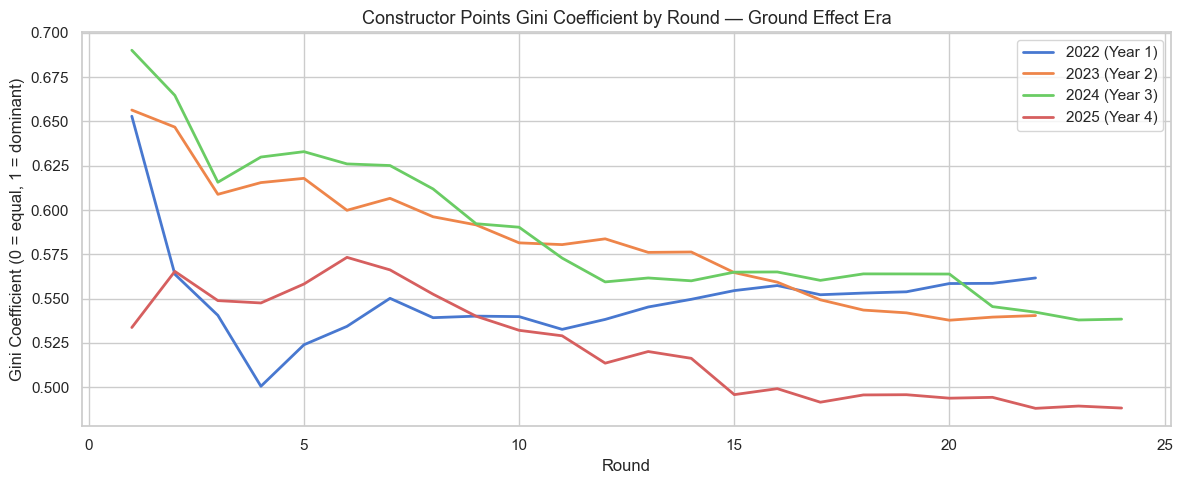


End-of-season Gini by year:
 season  final_round   gini
   2022           22 0.5616
   2023           22 0.5404
   2024           24 0.5384
   2025           24 0.4882


In [5]:
gini_df = points_gini_by_round(standings_df)
gini_df['era_year'] = gini_df['season'].apply(get_year_within_era)

fig, ax = plt.subplots(figsize=(12, 5))
for season in GROUND_EFFECT_SEASONS:
    season_gini = gini_df[gini_df['season'] == season]
    ax.plot(season_gini['round'], season_gini['gini'],
            label=f'{season} (Year {get_year_within_era(season)})', linewidth=2)

ax.set_title('Constructor Points Gini Coefficient by Round — Ground Effect Era', fontsize=13)
ax.set_xlabel('Round')
ax.set_ylabel('Gini Coefficient (0 = equal, 1 = dominant)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nEnd-of-season Gini by year:')
print(season_end_gini(standings_df).to_string(index=False))

## 2. Lap Time Field Spread

The **P1–P10 gap** is the difference in seconds between the fastest and 10th-fastest driver's best lap in each race.
A shrinking gap over era years indicates the field is converging on pace.

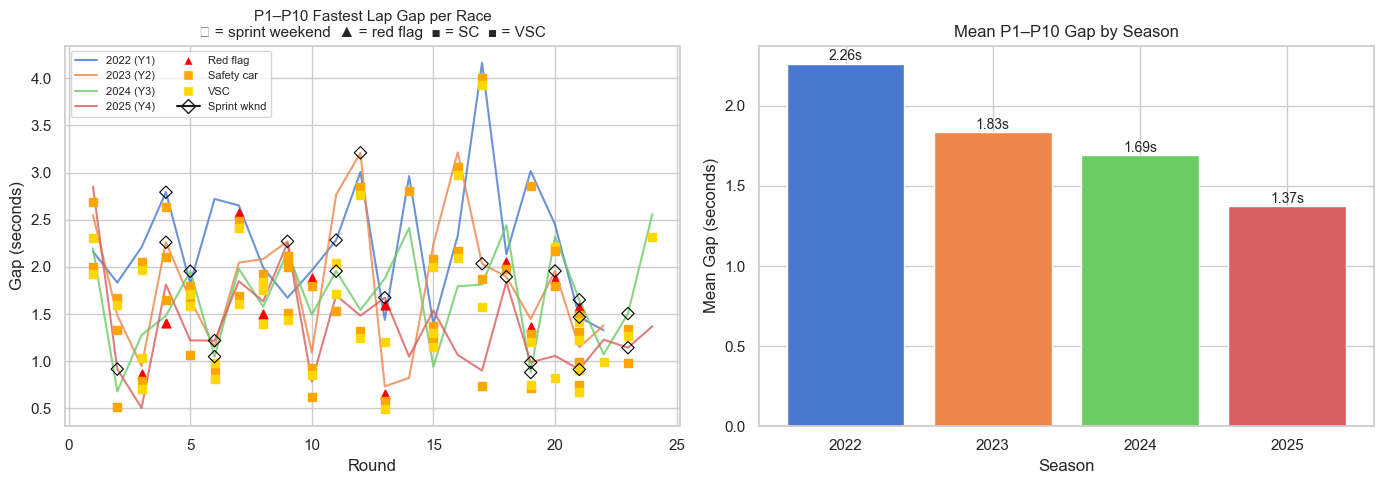


Mean P1–P10 gap by season:
 season  era_year  mean_gap_s  races
   2022         1       2.263     22
   2023         2       1.835     22
   2024         3       1.692     24
   2025         4       1.374     24

Mean P1–P10 gap — sprint weekends vs conventional:
  2022: conventional=2.28s  sprint wknd=2.18s  (n=3)
  2023: conventional=1.67s  sprint wknd=2.27s  (n=6)
  2024: conventional=1.76s  sprint wknd=1.50s  (n=6)
  2025: conventional=1.45s  sprint wknd=1.14s  (n=6)

Race control events affecting lap time data:
  Red flags:    11 races
  Safety cars:  49 races
  VSC:          42 races


In [6]:
delta_df = lap_time_delta_summary(all_laps)
delta_df['era_year'] = delta_df['season'].apply(get_year_within_era)

# Join sprint weekend and race control flags from results
race_meta = results_df[['season', 'round', 'is_sprint_weekend', 'had_sc', 'had_vsc', 'had_red_flag']].drop_duplicates()
delta_df = delta_df.merge(race_meta, on=['season', 'round'], how='left')

mean_df = mean_gap_by_season(delta_df)
mean_df['era_year'] = mean_df['season'].apply(get_year_within_era)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-race gaps
for season in GROUND_EFFECT_SEASONS:
    s = delta_df[delta_df['season'] == season]
    axes[0].plot(s['round'], s['gap_s'],
                 label=f'{season} (Y{get_year_within_era(season)})', linewidth=1.5, alpha=0.8)
    # Sprint weekend diamond overlay
    sprint_s = s[s['is_sprint_weekend'] == True]
    if not sprint_s.empty:
        axes[0].scatter(sprint_s['round'], sprint_s['gap_s'],
                        marker='D', s=40, zorder=5,
                        edgecolors='black', linewidths=0.8, facecolors='none')
    # Race control markers — plotted below the gap line
    offset = 0.08
    sc_s = s[s['had_sc'] == True]
    vsc_s = s[s['had_vsc'] == True]
    rf_s = s[s['had_red_flag'] == True]
    if not rf_s.empty:
        axes[0].scatter(rf_s['round'], rf_s['gap_s'] - offset,
                        marker='^', s=40, color='red', zorder=4, label='_nolegend_')
    if not sc_s.empty:
        axes[0].scatter(sc_s['round'], sc_s['gap_s'] - offset * 2,
                        marker='s', s=30, color='orange', zorder=4, label='_nolegend_')
    if not vsc_s.empty:
        axes[0].scatter(vsc_s['round'], vsc_s['gap_s'] - offset * 3,
                        marker='s', s=30, color='gold', zorder=4, label='_nolegend_')

# RC legend handles
from matplotlib.lines import Line2D
rc_handles = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=7, label='Red flag'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', markersize=7, label='Safety car'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gold', markersize=7, label='VSC'),
    Line2D([0], [0], marker='D', color='k', markerfacecolor='none', markersize=7, label='Sprint wknd'),
]
season_handles, season_labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=season_handles + rc_handles, fontsize=8, ncol=2)
axes[0].set_title('P1–P10 Fastest Lap Gap per Race\n◇ = sprint weekend  ▲ = red flag  ■ = SC  ■ = VSC', fontsize=11)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Gap (seconds)')

# Season mean
axes[1].bar(mean_df['season'].astype(str), mean_df['mean_gap_s'], color=sns.color_palette('muted', len(mean_df)))
axes[1].set_title('Mean P1–P10 Gap by Season', fontsize=12)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean Gap (seconds)')
for i, row in mean_df.iterrows():
    axes[1].text(i, row['mean_gap_s'] + 0.02, f"{row['mean_gap_s']:.2f}s", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nMean P1–P10 gap by season:')
print(mean_df[['season', 'era_year', 'mean_gap_s', 'races']].to_string(index=False))

# Sprint weekend vs conventional breakdown
print('\nMean P1–P10 gap — sprint weekends vs conventional:')
for season in GROUND_EFFECT_SEASONS:
    s = delta_df[delta_df['season'] == season]
    conv = s[~s['is_sprint_weekend']]['gap_s'].mean()
    sprt = s[s['is_sprint_weekend']]['gap_s'].mean()
    n_sprt = s['is_sprint_weekend'].sum()
    if n_sprt > 0:
        print(f'  {season}: conventional={conv:.2f}s  sprint wknd={sprt:.2f}s  (n={n_sprt})')
    else:
        print(f'  {season}: conventional={conv:.2f}s  no sprint weekends')

# Race control breakdown
print('\nRace control events affecting lap time data:')
rc = delta_df.drop_duplicates(['season', 'round'])
print(f'  Red flags:    {rc["had_red_flag"].sum()} races')
print(f'  Safety cars:  {rc["had_sc"].sum()} races')
print(f'  VSC:          {rc["had_vsc"].sum()} races')

## 3. Reliability — DNF Rates

DNF rate = retirements as a percentage of race starts, by constructor and season.

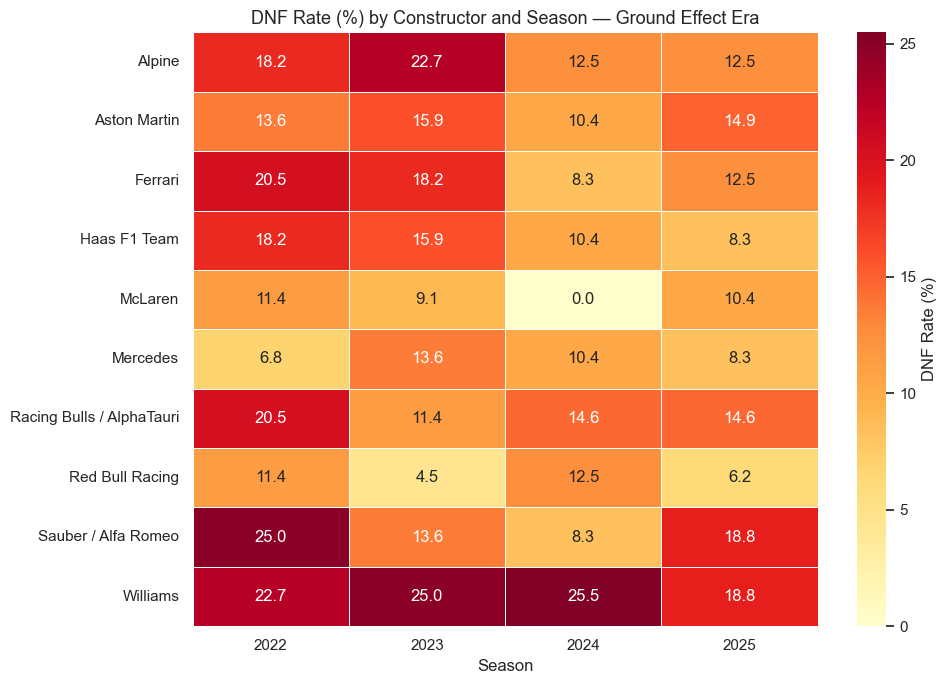


Most common DNF causes:
          status  count
         Retired    153
Collision damage     14
        Accident     11
       Collision     10
    Disqualified     10
   Did not start      9
          Engine      7
      Power Unit      6
         Gearbox      4
      Hydraulics      4


In [7]:
dnf_df = dnf_rate_by_constructor_year(results_df)

# Pivot for heatmap — constructors vs seasons
dnf_pivot = dnf_df.pivot_table(
    index='constructor_name', columns='season', values='dnf_rate_pct', fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(dnf_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'DNF Rate (%)'})
ax.set_title('DNF Rate (%) by Constructor and Season — Ground Effect Era', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nMost common DNF causes:')
print(dnf_causes(results_df).head(10).to_string(index=False))

## 4. Qualifying vs Race Position Conversion

**Position delta** = grid position − finishing position.
- Positive = gained places in the race
- Negative = lost places
- Zero = perfect conversion

DNFs are excluded from averages but counted separately.

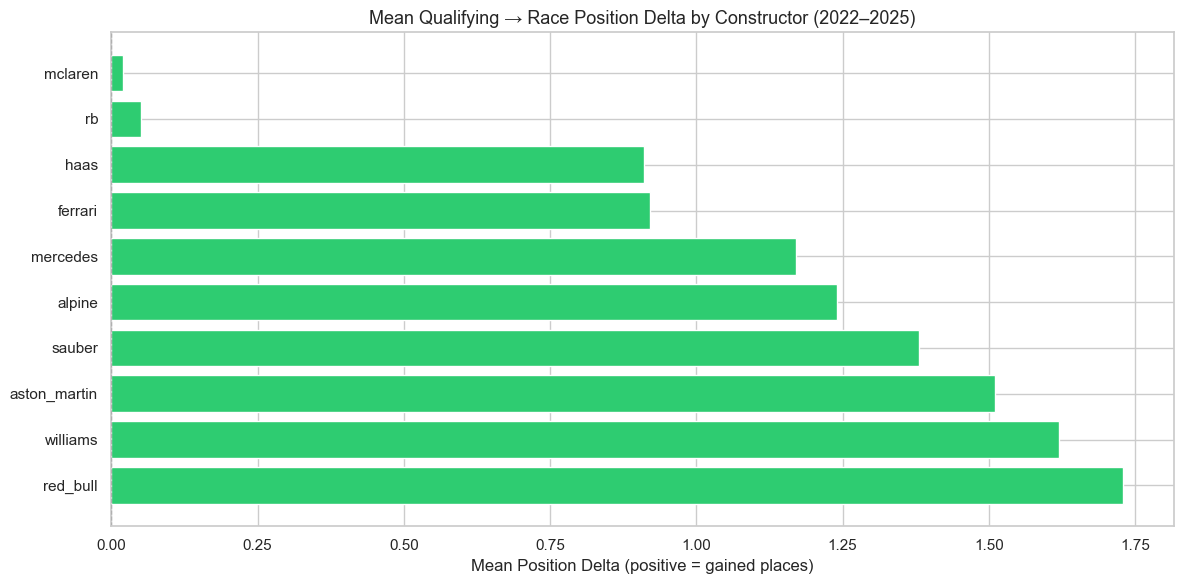


Constructor quali→race conversion (2022–2025):
constructor_id  races  mean_delta  dnf_count
      red_bull    168        1.73         16
      williams    141        1.62         42
  aston_martin    157        1.51         25
        sauber    152        1.38         30
        alpine    152        1.24         30
      mercedes    165        1.17         18
       ferrari    157        0.92         27
          haas    159        0.91         24
            rb    152        0.05         28
       mclaren    170        0.02         14


In [8]:
delta_results = quali_race_delta(results_df)
constructor_conv = mean_delta_by_constructor(delta_results)

fig, ax = plt.subplots(figsize=(12, 6))
colours = ['#2ecc71' if d >= 0 else '#e74c3c' for d in constructor_conv['mean_delta']]
bars = ax.barh(constructor_conv['constructor_id'], constructor_conv['mean_delta'], color=colours)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Qualifying → Race Position Delta by Constructor (2022–2025)', fontsize=13)
ax.set_xlabel('Mean Position Delta (positive = gained places)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nConstructor quali→race conversion (2022–2025):')
print(constructor_conv[['constructor_id', 'races', 'mean_delta', 'dnf_count']].to_string(index=False))

## Baseline Summary

Record key observations here as you run the notebook — these will inform the 2026 comparison.

| Metric | Observation |
|---|---|
| Points Gini | 2022 was an anomaly, however all other years trended downwards (tighter convergence) |
| Lap time convergence | Lap times trended downwards every single year |
| Least reliable constructor | Failure rates appear to trend towards improving for most teams, it will be interesting to see what the real trends show and reflect on team performance in the Contructors Championship - e.g. teams missing out on valuable points that impacted on these positions |
| Best quali→race converter | No real immediate trend analysis without delving further into related dataset comparisons - but Racing Bulls appeared to be better at Qualifying than race results. |

**Proceed to `02_2026_era_year1.ipynb` once 2026 data is available (Miami onward).**